In [94]:
from pathlib import Path
import sys
 
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
 

In [95]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import json
 
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold          # FIX 1: was KFold
from sklearn.metrics import accuracy_score                   # FIX 2: was missing
 
from src.utils.seed import set_seed
from src.models.deepconvnet import DeepConvNet
from src.models.projection_head import ProjectionHead
from src.losses.icrr_loss import icrr_loss
from src.evaluation.ess import compute_ess
 

In [96]:
SEED = 42
set_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
EPOCHS      = 50          # FIX 3: was 25; NB06 and NB07 both use 50
LR          = 1e-3
LAMBDA_ICRR = 0.5
N_SPLITS    = 5
 

In [97]:
DATA_DIR    = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR  = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
 
ABLATION_TABLE_DIR = TABLES_DIR  / "projection_head_ablation"   # FIX 4: own subdir
EMBED_FIG_DIR      = FIGURES_DIR / "embedding_geometry"
MODEL_COMP_FIG_DIR = FIGURES_DIR / "model_comparisons"
 
for p in [ABLATION_TABLE_DIR, EMBED_FIG_DIR, MODEL_COMP_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)
 
DATA_PATH = DATA_DIR / "bnci_dataset" / "processed" / "preprocessed_BNCI.npz"

In [98]:
data = np.load(DATA_PATH, allow_pickle=True)
X = data["X"].astype(np.float32)
y = data["y"].astype(int)
 
chans    = X.shape[1]     # 25
samples  = X.shape[2]     # 561
n_classes = len(np.unique(y))  # 4
 
print("BNCI Shape:", X.shape)
print("Classes:", np.unique(y))

BNCI Shape: (640, 25, 561)
Classes: [0 1 2 3]


In [99]:
def train_one_fold(backbone, projector, classifier, X_train, y_train, lambda_icrr):
 
    backbone.train()
    projector.train()
    classifier.train()
 
    optimizer = optim.Adam(
        list(backbone.parameters()) +
        list(projector.parameters()) +
        list(classifier.parameters()),
        lr=LR
    )
 
    criterion = nn.CrossEntropyLoss()
 
    dataset = TensorDataset(
        torch.tensor(X_train).float(),
        torch.tensor(y_train).long()
    )
 
    loader = DataLoader(dataset, batch_size=32, shuffle=True)  # FIX 6: batch 32, matches NB07
 
    for epoch in range(EPOCHS):
        for xb, yb in loader:
 
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
 
            optimizer.zero_grad()
 
            # Backbone embedding
            _, z = backbone(xb, return_embedding=True)
 
            # Projection (may be nn.Identity for baseline/icrr conditions)
            z_proj = projector(z)
 
            # Classification head
            logits = classifier(z_proj)
 
            ce_loss = criterion(logits, yb)
 
            # ICRR regularization in backbone space
            if lambda_icrr > 0:
                reg  = icrr_loss(z, yb)
                loss = ce_loss + lambda_icrr * reg
            else:
                loss = ce_loss
 
            loss.backward()
            optimizer.step()

In [100]:
def evaluate_fold(backbone, projector, classifier, X_test, y_test):
 
    backbone.eval()
    projector.eval()
    classifier.eval()
 
    all_preds      = []
    all_embeddings = []   # backbone space
 
    dataset = TensorDataset(
        torch.tensor(X_test).float(),
        torch.tensor(y_test).long()
    )
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
 
    with torch.no_grad():
        for xb, yb in loader:
 
            xb = xb.to(DEVICE)
 
            # Backbone embedding (used for ESS)
            _, z = backbone(xb, return_embedding=True)
 
            # Projection + classification (used for accuracy)
            z_proj = projector(z)
            logits = classifier(z_proj)
 
            all_preds.append(torch.argmax(logits, dim=1).cpu().numpy())
            all_embeddings.append(z.cpu().numpy())   # backbone space
 
    preds      = np.concatenate(all_preds)
    embeddings = np.concatenate(all_embeddings)
 
    acc = accuracy_score(y_test, preds)
    ess = compute_ess(embeddings, y_test)   # backbone-space ESS
 
    return acc, ess, embeddings

In [105]:
def run_kfold(model_type, lambda_icrr):
 
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
 
    fold_accs   = []
    fold_esses  = []
    all_embeddings = []
    all_labels     = []
 
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
 
        print(f"  Fold {fold}/{N_SPLITS}", end=" ")
 
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
 
        # Fresh backbone each fold
        backbone = DeepConvNet(chans, samples, n_classes).to(DEVICE)
 
        # Infer backbone embedding dimension
        dummy = torch.zeros(1, chans, samples).to(DEVICE)
        with torch.no_grad():
            _, z_dummy = backbone(dummy, return_embedding=True)
        backbone_dim = z_dummy.shape[1]
 
        # Build projector and classifier based on condition
        if model_type in ["baseline", "icrr"]:
            # No projection: identity pass-through
            projector  = nn.Identity().to(DEVICE)
            classifier = nn.Linear(backbone_dim, n_classes).to(DEVICE)
 
        else:  # "projection" or implicitly projection+icrr
            projector = ProjectionHead(backbone_dim).to(DEVICE)
 
            # Infer projection output dim
            with torch.no_grad():
                z_proj_dummy = projector(z_dummy)
            proj_dim   = z_proj_dummy.shape[1]
            classifier = nn.Linear(proj_dim, n_classes).to(DEVICE)
 
        # Train
        train_one_fold(backbone, projector, classifier, X_train, y_train, lambda_icrr)
 
        # Evaluate — ESS is in backbone space
        acc, ess, emb = evaluate_fold(backbone, projector, classifier, X_test, y_test)
 
        print(f"→ acc: {acc:.4f}  ess: {ess:.4f}")
 
        fold_accs.append(acc)
        fold_esses.append(ess)
        all_embeddings.append(emb)
        all_labels.append(y_test)
 
    all_embeddings = np.concatenate(all_embeddings)
    all_labels     = np.concatenate(all_labels)
 
    return (
        np.array(fold_accs),
        np.array(fold_esses),
        all_embeddings,
        all_labels
    )
 

In [106]:
conditions = {
    "baseline"        : ("baseline",    0),
    "projection"      : ("projection",  0),
    "icrr"            : ("icrr",        LAMBDA_ICRR),
    "projection_icrr" : ("projection",  LAMBDA_ICRR),
}
 
results       = {}
raw_fold_data = {}
embeddings_by_condition = {}
 
for cond_name, (model_type, lam) in conditions.items():
    print(f"\n=== {cond_name.upper()} (lambda={lam}) ===")
 
    accs, esses, emb, labels = run_kfold(model_type, lam)
 
    results[cond_name] = {
        "mean_acc" : float(np.mean(accs)),
        "std_acc"  : float(np.std(accs)),
        "mean_ess" : float(np.mean(esses)),
        "std_ess"  : float(np.std(esses))
    }
 
    raw_fold_data[cond_name] = {
        "fold_acc" : accs.tolist(),
        "fold_ess" : esses.tolist()
    }
 
    embeddings_by_condition[cond_name] = (emb, labels)
 
    np.savez(
        ABLATION_TABLE_DIR / f"embeddings_{cond_name}.npz",
        embeddings=emb,
        labels=labels
    )
 


=== BASELINE (lambda=0) ===
  Fold 1/5 → acc: 0.7578  ess: 39.5504
  Fold 2/5 → acc: 0.7656  ess: 39.0696
  Fold 3/5 → acc: 0.6250  ess: 40.3879
  Fold 4/5 → acc: 0.7344  ess: 40.9650
  Fold 5/5 → acc: 0.7266  ess: 40.9511

=== PROJECTION (lambda=0) ===
  Fold 1/5 → acc: 0.7188  ess: 51.1573
  Fold 2/5 → acc: 0.6875  ess: 55.0973
  Fold 3/5 → acc: 0.6016  ess: 56.8235
  Fold 4/5 → acc: 0.6016  ess: 57.2160
  Fold 5/5 → acc: 0.7109  ess: 52.4998

=== ICRR (lambda=0.5) ===
  Fold 1/5 → acc: 0.7031  ess: 20.0947
  Fold 2/5 → acc: 0.7266  ess: 20.5509
  Fold 3/5 → acc: 0.6406  ess: 21.9305
  Fold 4/5 → acc: 0.6562  ess: 22.6102
  Fold 5/5 → acc: 0.6328  ess: 22.5635

=== PROJECTION_ICRR (lambda=0.5) ===
  Fold 1/5 → acc: 0.6953  ess: 18.4161
  Fold 2/5 → acc: 0.6484  ess: 21.3572
  Fold 3/5 → acc: 0.6172  ess: 19.1953
  Fold 4/5 → acc: 0.6250  ess: 19.3869
  Fold 5/5 → acc: 0.5703  ess: 19.9923


In [107]:
with open(ABLATION_TABLE_DIR / "ablation_summary.json", "w") as f:
    json.dump(results, f, indent=4)

with open(ABLATION_TABLE_DIR / "ablation_fold_metrics.json", "w") as f:
    json.dump(raw_fold_data, f, indent=4)

df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "condition"})
)
df.to_csv(ABLATION_TABLE_DIR / "ablation_table.csv", index=False)

print("\n===== ABLATION SUMMARY (ESS in backbone space) =====")
print(df.to_string(index=False))


===== ABLATION SUMMARY (ESS in backbone space) =====
      condition  mean_acc  std_acc  mean_ess  std_ess
       baseline  0.721875 0.050534 40.184805 0.759382
     projection  0.664062 0.052057 54.558782 2.378622
           icrr  0.671875 0.036644 21.549962 1.040413
projection_icrr  0.631250 0.040865 19.669567 0.982699


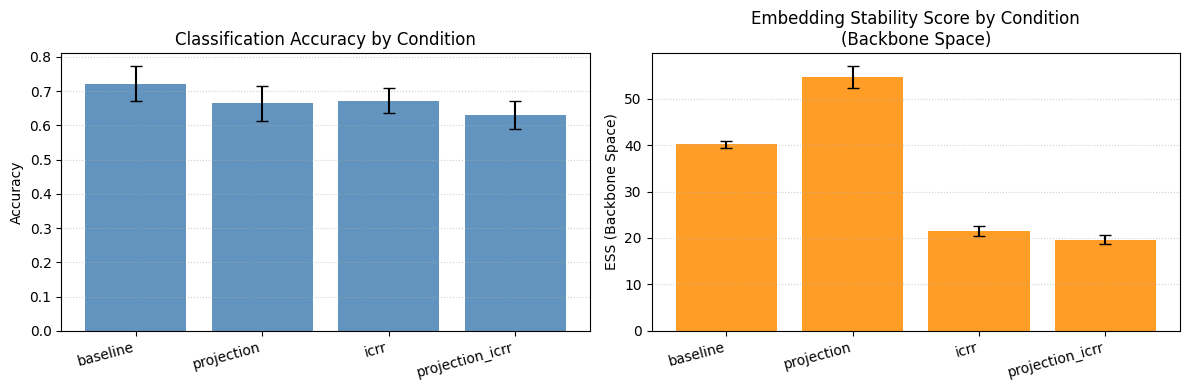

In [108]:
cond_labels = list(results.keys())
mean_accs   = [results[c]["mean_acc"] for c in cond_labels]
std_accs    = [results[c]["std_acc"]  for c in cond_labels]
mean_esses  = [results[c]["mean_ess"] for c in cond_labels]
std_esses   = [results[c]["std_ess"]  for c in cond_labels]

x = np.arange(len(cond_labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].bar(x, mean_accs, yerr=std_accs, capsize=4, color="steelblue", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cond_labels, rotation=15, ha="right")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Classification Accuracy by Condition")
axes[0].grid(axis="y", linestyle=":", alpha=0.6)

# ESS
axes[1].bar(x, mean_esses, yerr=std_esses, capsize=4, color="darkorange", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cond_labels, rotation=15, ha="right")
axes[1].set_ylabel("ESS (Backbone Space)")
axes[1].set_title("Embedding Stability Score by Condition\n(Backbone Space)")
axes[1].grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(MODEL_COMP_FIG_DIR / "projection_ablation_acc_ess.png", dpi=300, bbox_inches="tight")
plt.show()